<a href="https://colab.research.google.com/github/zsx8/R4DS/blob/main/Introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data visualization

## Introduction

### ggplot2

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
# install.packages("palmerpenguins")
library(palmerpenguins)
# penguins data frame containing body measurements for penguins on three islands in the Palmer Archipelago


Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw




In [3]:
# install.packages("ggthemes")
library(ggthemes)
# a colorblind safe color palette

In [4]:
# Do penguins with longer flippers weigh more or less than penguins with shorter flippers?
# Does the relationship vary by the species of the penguin? How about by the island where the penguin lives?

In [5]:
# penguins
# View(penguins)
glimpse(penguins)

Rows: 344
Columns: 8
$ species           <fct> Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adel…
$ island            <fct> Torgersen, Torgersen, Torgersen, Torgersen, Torgerse…
$ bill_length_mm    <dbl> 39.1, 39.5, 40.3, NA, 36.7, 39.3, 38.9, 39.2, 34.1, …
$ bill_depth_mm     <dbl> 18.7, 17.4, 18.0, NA, 19.3, 20.6, 17.8, 19.6, 18.1, …
$ flipper_length_mm <int> 181, 186, 195, NA, 193, 190, 181, 195, 193, 190, 186…
$ body_mass_g       <int> 3750, 3800, 3250, NA, 3450, 3650, 3625, 4675, 3475, …
$ sex               <fct> male, female, female, NA, female, male, female, male…
$ year              <int> 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007…


In [6]:
?penguins

In [7]:
# species: a penguin’s species (Adelie, Chinstrap, or Gentoo).
# island: a factor denoting island (Biscoe, Dream or Torgersen).
# bill_length_mm: a number denoting bill length (millimeters)
# bill_depth_mm: a number denoting bill depth (millimeters)
# flipper_length_mm: length of a penguin’s flipper, in millimeters.
# body_mass_g: body mass of a penguin, in grams.
# sex: a factor denoting penguin sex (female, male)
# year: an integer denoting the study year (2007, 2008, or 2009)

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


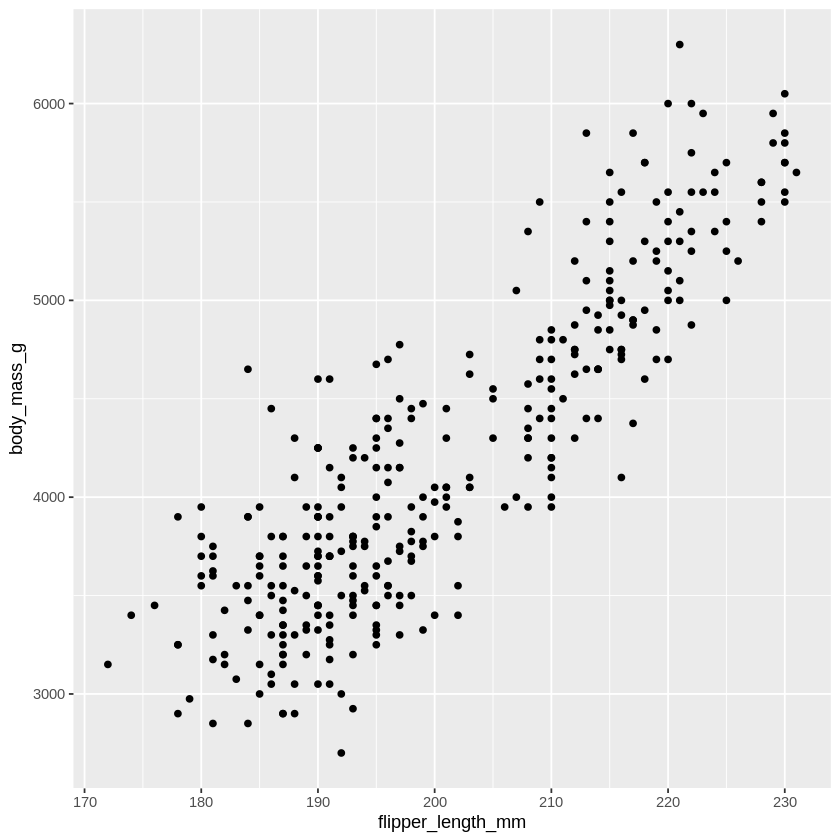

In [8]:
ggplot(data = penguins, # defining a plot object that you then add layers to
       mapping = aes(x = flipper_length_mm, y = body_mass_g) # how variables in your dataset are mapped to visual properties (aesthetics)
       ) +
         geom_point() # the geometrical object that a plot uses to represent data
       # scatterplot

       # The relationship appears to be positive

In [9]:
# bar charts use bar geoms (geom_bar()),
# line charts use line geoms (geom_line()),
# boxplots use boxplot geoms (geom_boxplot()),
# scatterplots use point geoms (geom_point())

In [10]:
# Scatterplots are useful for displaying the relationship between two numerical variables
# Does the relationship between flipper length and body mass differ by species?

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


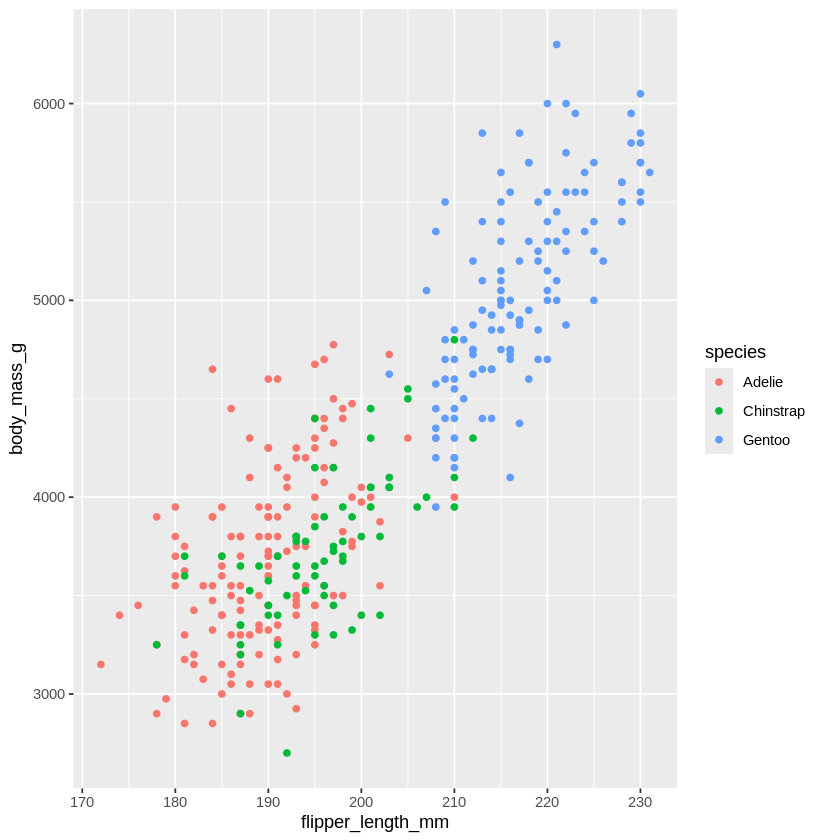

In [11]:
ggplot(data = penguins,
       mapping = aes(x = flipper_length_mm, y = body_mass_g, color = species) # scaling
       ) +
         geom_point()

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


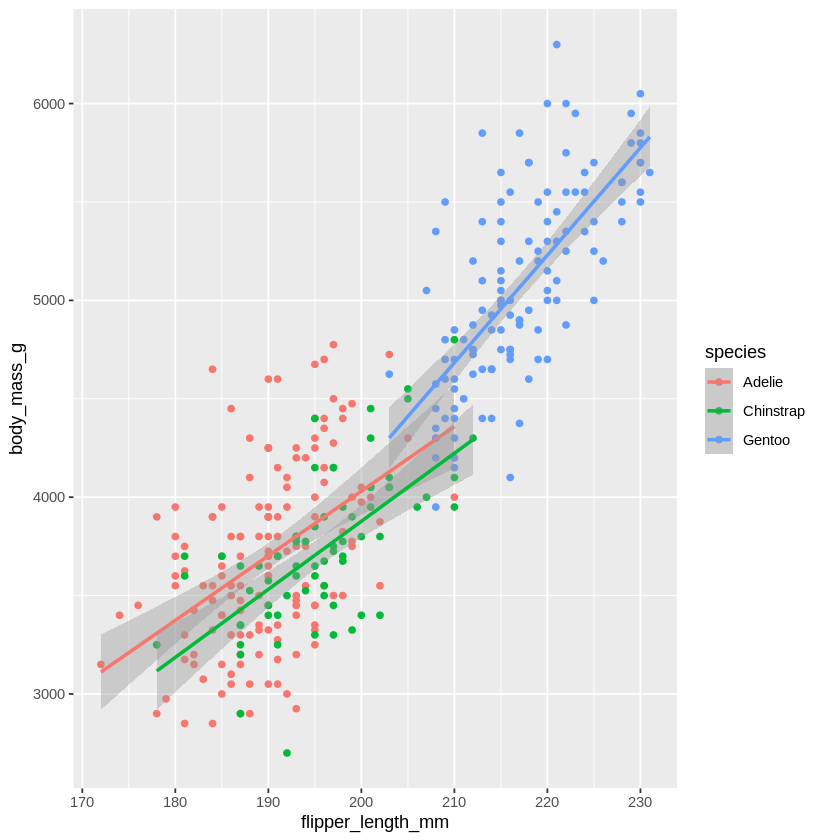

In [12]:
ggplot(data = penguins,
       mapping = aes(x = flipper_length_mm, y = body_mass_g, color = species)
       ) +
         geom_point() +
         geom_smooth(method = "lm") # linear model

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


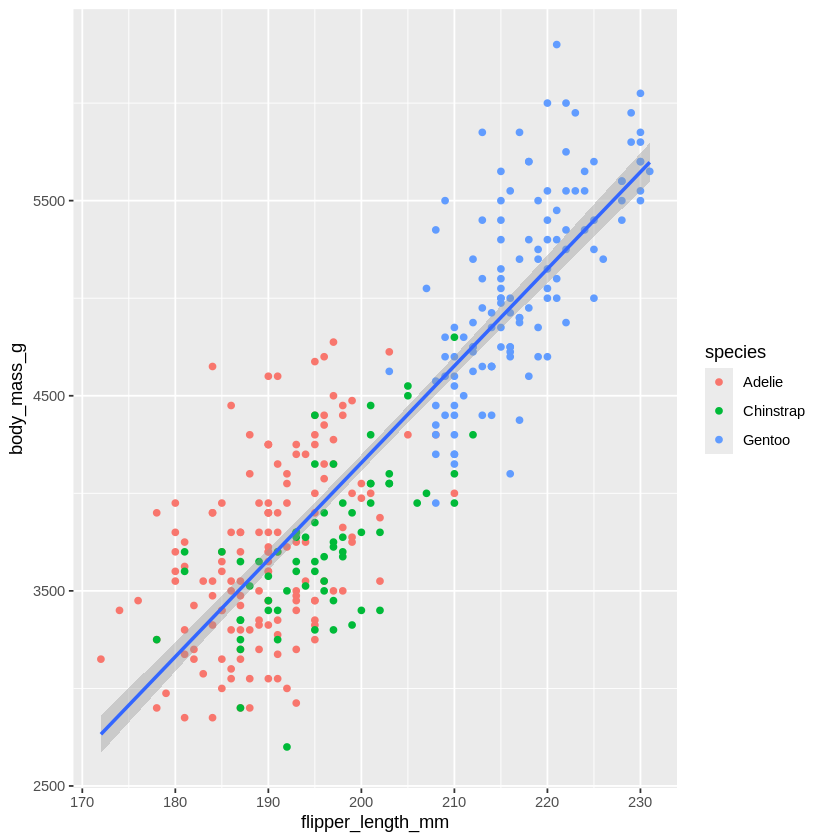

In [13]:
ggplot(data = penguins,
       mapping = aes(x = flipper_length_mm, y = body_mass_g)
       ) +
         geom_point(mapping = aes(color = species)) +
         geom_smooth(method = "lm")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


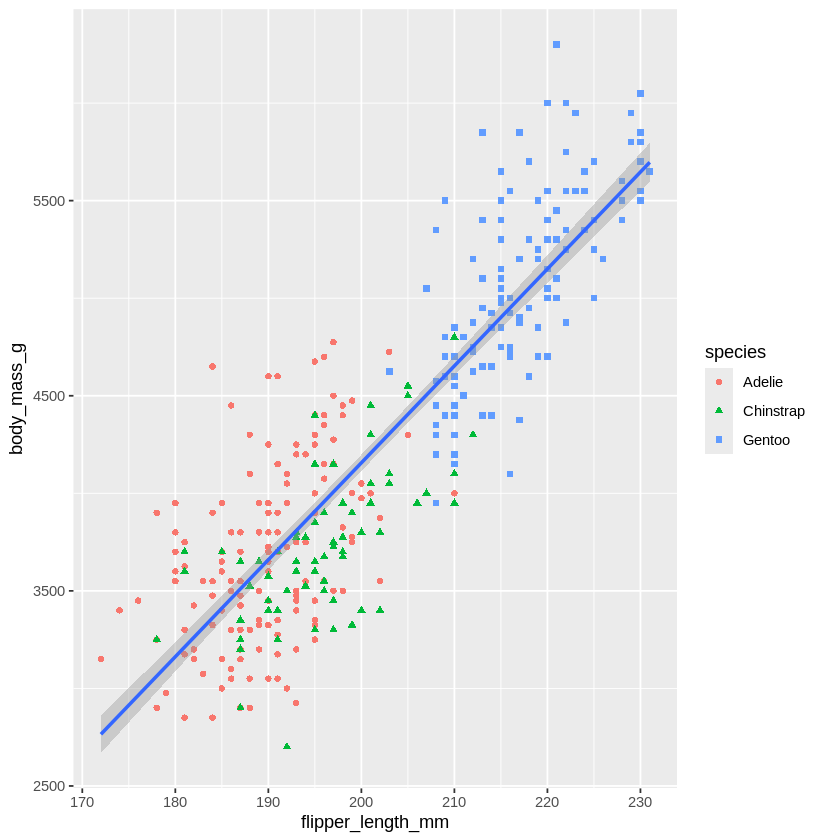

In [14]:
ggplot(
  data = penguins,
  mapping = aes(x = flipper_length_mm, y = body_mass_g)
) +
  geom_point(mapping = aes(color = species, shape = species)) +
  geom_smooth(method = "lm")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


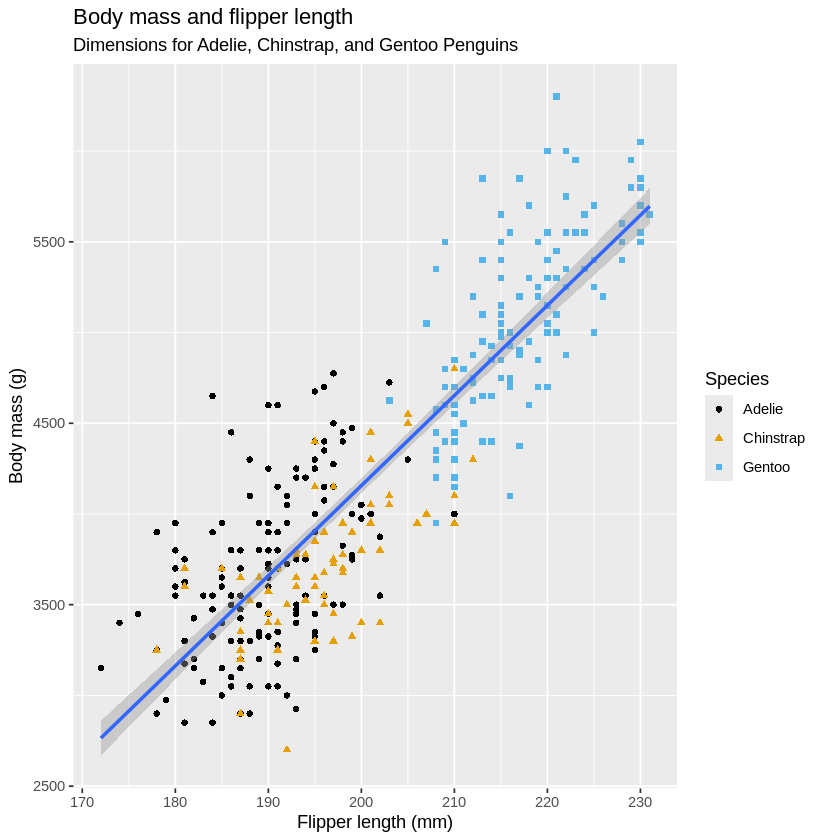

In [15]:
ggplot(
  data = penguins,
  mapping = aes(x = flipper_length_mm, y = body_mass_g)
) +
  geom_point(aes(color = species, shape = species)) +
  geom_smooth(method = "lm") +
  labs(
    title = "Body mass and flipper length",
    subtitle = "Dimensions for Adelie, Chinstrap, and Gentoo Penguins",
    x = "Flipper length (mm)", y = "Body mass (g)",
    color = "Species", shape = "Species"
  ) +
  scale_color_colorblind() # improve the color palette to be colorblind safe